#### EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

In [2]:
# Set plot style
sns.set_theme(style="whitegrid")

In [4]:
#load dataset
farms = pd.read_csv("C:/Users/Vasmai/dataset/farm_boundaries_cleaned.csv")
print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        Clay  6.2      1959         24.0        585     0.36   
1        2        Clay  6.2      1959         24.0        481     0.48   
2        3  Sandy Loam  8.2      2021         25.0        179     1.18   
3        4  Sandy Loam  5.9      2554         24.0        260     0.46   
4        5        Clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  
0  126.675704 -8.568798      True  
1  126.680149 -8.567578   

In [5]:
print(farms.info())
print(farms.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   farm_id      3200 non-null   int64  
 1   texture      3200 non-null   object 
 2   ph           3200 non-null   float64
 3   rainfall     3200 non-null   int64  
 4   temperature  3200 non-null   float64
 5   elevation    3200 non-null   int64  
 6   area_ha      3200 non-null   float64
 7   geometry     3200 non-null   object 
 8   coastal      3200 non-null   bool   
 9   slope        3200 non-null   float64
 10  longitude    3200 non-null   float64
 11  latitude     3200 non-null   float64
 12  riparian     3200 non-null   bool   
dtypes: bool(2), float64(6), int64(3), object(2)
memory usage: 281.4+ KB
None
           farm_id           ph     rainfall  temperature    elevation  \
count  3200.000000  3200.000000  3200.000000  3200.000000  3200.000000   
mean   1600.500000     6.983094  1807

In [10]:
print(farms.isnull().sum())

farm_id        0
texture        0
ph             0
rainfall       0
temperature    0
elevation      0
area_ha        0
geometry       0
coastal        0
slope          0
longitude      0
latitude       0
riparian       0
dtype: int64


In [22]:
# Select all numeric types (floats and integers)
farms_num_cols = farms.select_dtypes(include=[np.number]).columns.tolist()

# Remove the id column
farms_num_cols.remove("farm_id")

# Convert the 'soil_texture' column to lowercase
farms["texture"] = farms["texture"].str.lower()

# Select object  types
farms_cat_cols = farms.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  
0  126.675704 -8.568798      True  
1  126.680149 -8.567578   

#### Distribution

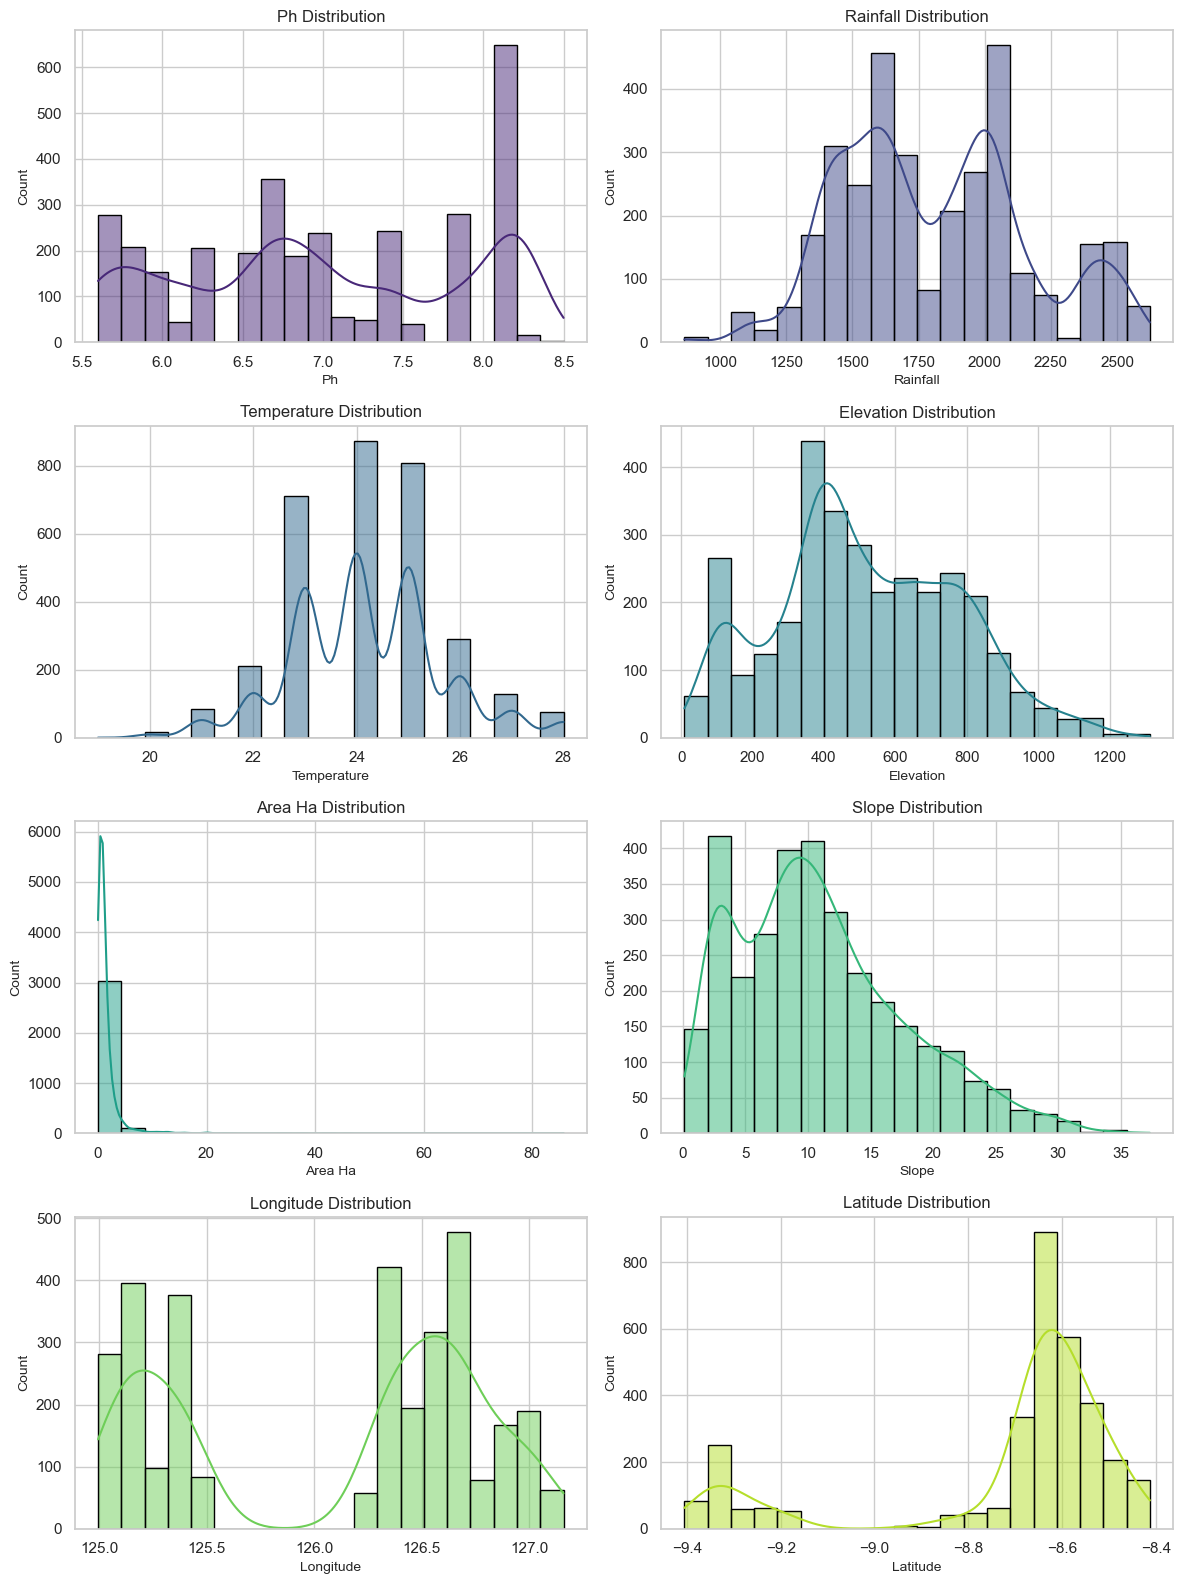

In [26]:
import math

# Dynamic grid calculation
num_plots = len(farms_num_cols)
cols_grid = 2  
rows_grid = math.ceil(num_plots / cols_grid)

# Choose a color palette
colors = sns.color_palette("viridis", num_plots) 

# Create figure
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_num_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)
    sns.histplot(farms[col], kde=True, color=colors[i], bins=20, edgecolor='black')
    plt.title(f"{col.replace('_', ' ').title()} Distribution", fontsize=12)
    plt.xlabel(col.replace("_", " ").title(), fontsize=10)
    plt.ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

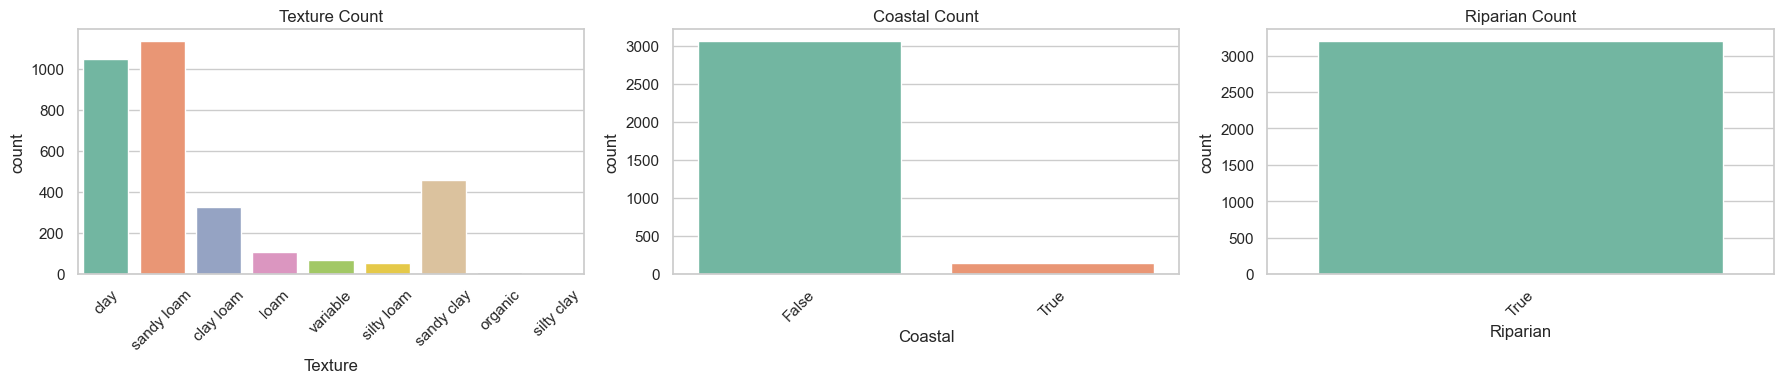

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select categorical columns with less than 20 unique values
categorical_cols = [col for col in farms_cat_cols if farms[col].nunique() < 20]

num_plots = len(categorical_cols)
cols = 3  # number of plots per row
rows = (num_plots + cols - 1) // cols  # calculate number of rows needed

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()  # flatten for easy indexing

# Plot each categorical column
for i, column in enumerate(categorical_cols):
    sns.countplot(
        data=farms,
        x=column,
        hue=column,          
        palette="Set2",
        ax=axes[i],
        dodge=False,          
        legend=False          
    )
    
    axes[i].set_title(f"{column.replace('_', ' ').title()} Count")
    axes[i].set_xlabel(column.replace("_", " ").title())
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Heatmap

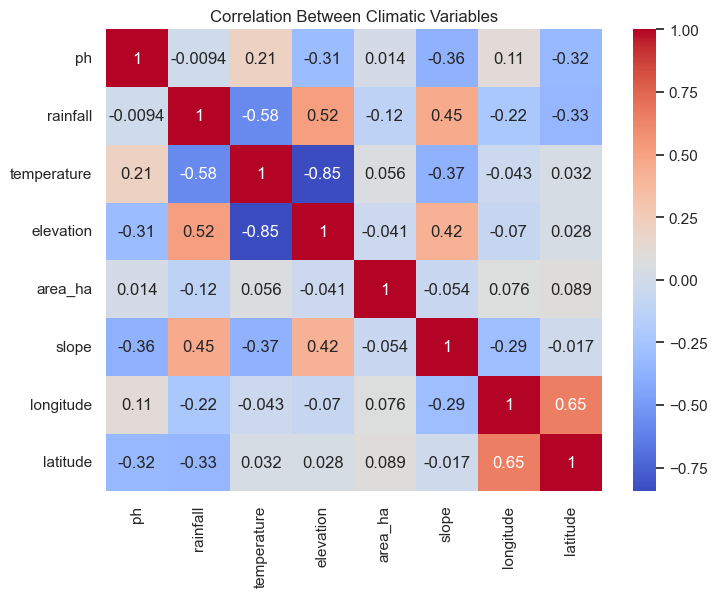

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(farms[farms_num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Climatic Variables")
plt.show()

### Clustering

#### Numeric features for clustering

In [68]:
# Exclude ID, geometry, longitude/latitude (keep only climate-related numeric features)
exclude_cols = ["farm_id", "geometry", "longitude", "latitude"]
farms_num_cols = [col for col in farms.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

print("Numeric features used for clustering:", farms_num_cols)

Numeric features used for clustering: ['ph', 'rainfall', 'temperature', 'elevation', 'area_ha', 'slope', 'Farm_Archetype']


In [77]:

# Standardize numeric data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(farms[farms_num_cols])

print("Shape of scaled data:", X_scaled.shape)

Shape of scaled data: (3200, 7)


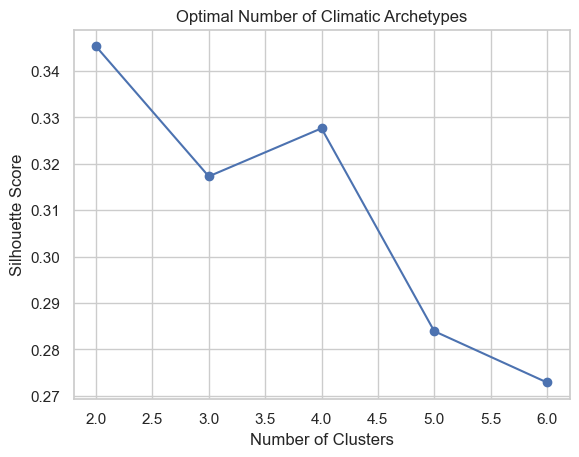

In [74]:
#Determine optimal number of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K_range = range(2, 7)  # test 2–6 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Optimal Number of Climatic Archetypes")
plt.show()


#### K-mean cluster

In [75]:

# Apply K-Means clustering

optimal_k = 3  # replace with best k from silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
farms["Farm_Archetype"] = kmeans.fit_predict(X_scaled)

# Cluster centroids (archetype profiles)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=farms_num_cols)
print("Farm Archetype Profiles (Centroids):")
print(centroids)

Farm Archetype Profiles (Centroids):
         ph     rainfall  temperature   elevation   area_ha      slope  \
0  6.338648  2025.417678    23.073657  724.035529  1.023414  16.221974   
1  7.082457  1509.653590    25.173945  352.480385  1.919652   6.448483   
2  7.860000  2025.823022    24.149640  494.798561  1.079986  11.013388   

   Farm_Archetype  
0    1.310063e-14  
1    1.000000e+00  
2    2.000000e+00  


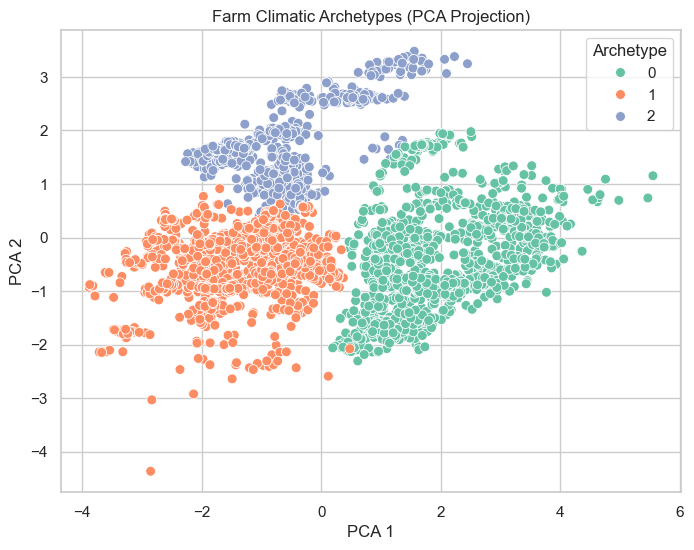

Number of farms per archetype:
Farm_Archetype
1    1351
0    1154
2     695
Name: count, dtype: int64
Number of numeric columns used: 7
Shape of cluster centers: (3, 7)


In [78]:
# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=farms["Farm_Archetype"], palette="Set2", s=50)
plt.title("Farm Climatic Archetypes (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Archetype")
plt.show()

print("Number of farms per archetype:")
print(farms["Farm_Archetype"].value_counts())

print("Number of numeric columns used:", len(farms_num_cols))
print("Shape of cluster centers:", kmeans.cluster_centers_.shape)

### Categorical analysis to complement climatic archetypes

In [49]:
# Select relevant categorical columns
farms_cat_cols = ["texture", "coastal", "riparian"]

# Quick check
for col in farms_cat_cols:
    print(col, farms[col].value_counts())

texture texture
sandy loam    1135
clay          1049
sandy clay     456
clay loam      325
loam           105
variable        66
silty loam      53
organic         10
silty clay       1
Name: count, dtype: int64
coastal coastal
False    3060
True      140
Name: count, dtype: int64
riparian riparian
True    3200
Name: count, dtype: int64


#### Count categorical features per archetype

In [50]:
# For each archetype, see distribution of categories
for col in farms_cat_cols:
    print(f"\nDistribution of {col} by Farm Archetype:\n")
    print(pd.crosstab(farms["Farm_Archetype"], farms[col], margins=True))


Distribution of texture by Farm Archetype:

texture         clay  clay loam  loam  organic  sandy clay  sandy loam  \
Farm_Archetype                                                           
0                280         83     7        0         309         427   
1                698        231    74       10         147         361   
2                 71         11    24        0           0         347   
All             1049        325   105       10         456        1135   

texture         silty clay  silty loam  variable   All  
Farm_Archetype                                          
0                        0          42        14  1162  
1                        1          11        39  1572  
2                        0           0        13   466  
All                      1          53        66  3200  

Distribution of coastal by Farm Archetype:

coastal         False  True   All
Farm_Archetype                   
0                1162     0  1162
1                1435

#### Plot Categorical features per archetype

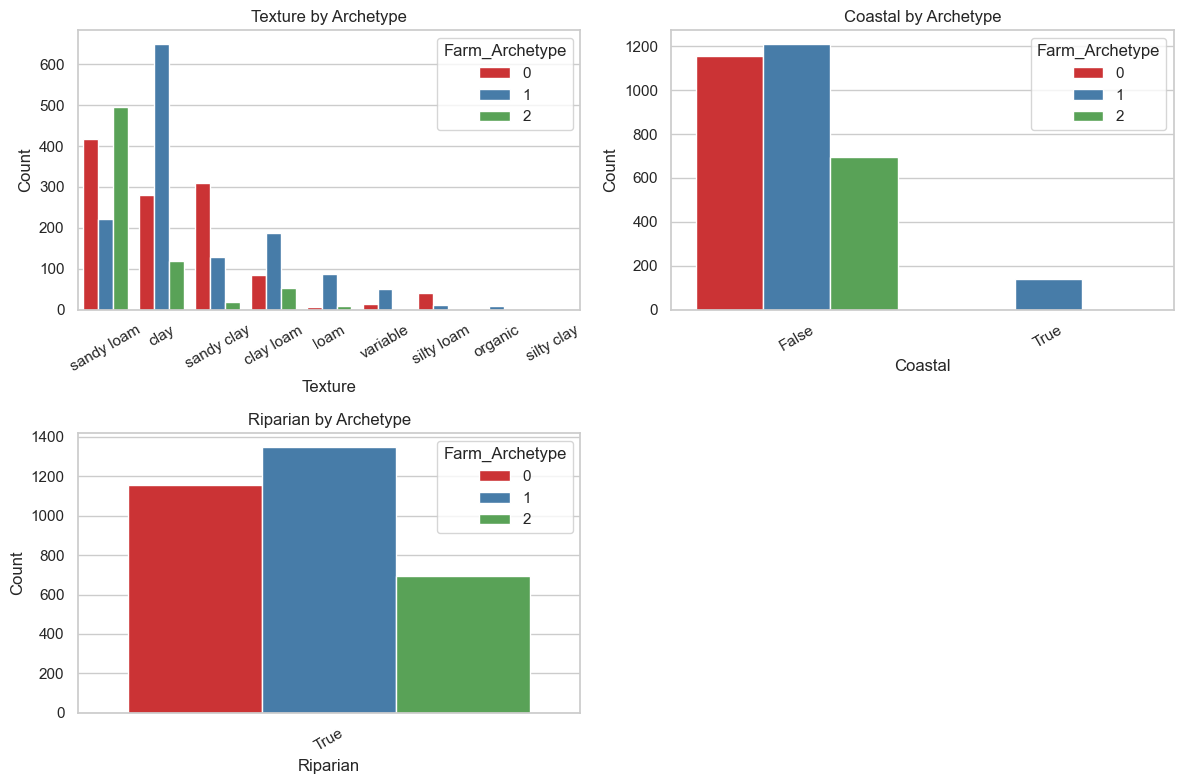

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  Farm_Archetype  
0  126.675704 -8.568798      True             

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_grid = 2
rows_grid = math.ceil(len(farms_cat_cols) / cols_grid)
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_cat_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)
    sns.countplot(
        data=farms,
        x=col,
        hue="Farm_Archetype",
        palette="Set1",
        order=farms[col].value_counts().index
    )
    plt.title(f"{col.title()} by Archetype")
    plt.xlabel(col.title())
    plt.ylabel("Count")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(farms.head())

In [84]:
numeric_summary = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=farms_num_cols
).round(2)
numeric_summary["Farm_Archetype"] = numeric_summary.index
numeric_summary

# Soil texture percentages per archetype
categorical_cols = ["texture"]  # you can add 'coastal','riparian' if needed
cat_summary = pd.crosstab(farms["Farm_Archetype"], farms["texture"])

# Convert counts to percentages
cat_summary_pct = cat_summary.div(cat_summary.sum(axis=1), axis=0).round(2) * 100
cat_summary_pct

archetype_profile = numeric_summary.set_index("Farm_Archetype").join(cat_summary_pct)
archetype_profile

,ph,rainfall,temperature,elevation,area_ha,slope,clay,clay loam,loam,organic,sandy clay,sandy loam,silty clay,silty loam,variable
Farm_Archetype,,,,,,,,,,,,,,,
0,6.34,2025.42,23.07,724.04,1.02,16.22,24.0,7.0,1.0,0.0,27.0,36.0,0.0,4.0,1.0
1,7.08,1509.65,25.17,352.48,1.92,6.45,48.0,14.0,7.0,1.0,9.0,17.0,0.0,1.0,4.0
2,7.86,2025.82,24.15,494.80,1.08,11.01,17.0,8.0,1.0,0.0,3.0,71.0,0.0,0.0,0.0


each row = one archetype, columns = numeric + categorical

#### Display 

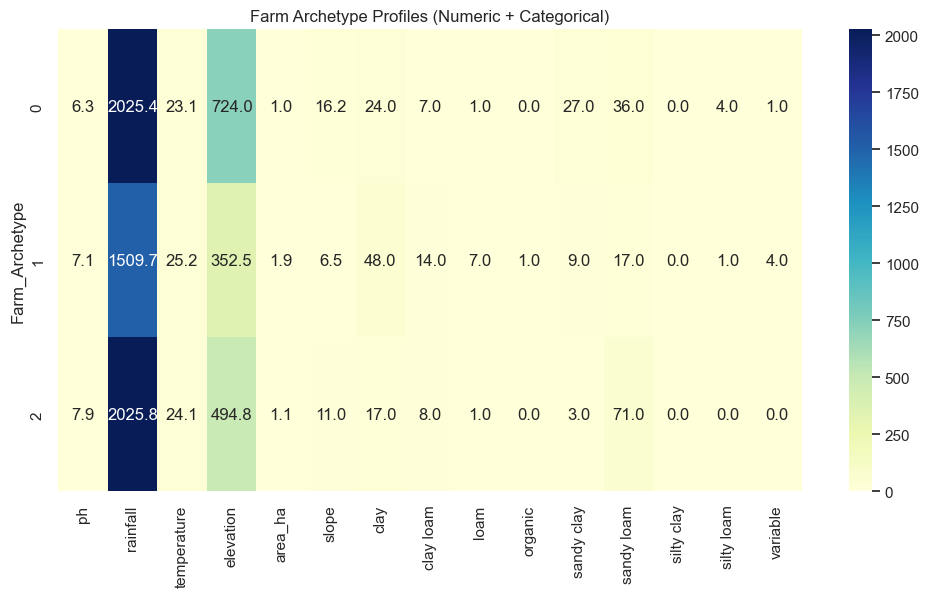

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(archetype_profile, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Farm Archetype Profiles (Numeric + Categorical)")
plt.show()

In [89]:
import os

# CSV file path
csv_file_path = os.path.join("C:/Users/Vasmai/dataset", "farm_climatic_archetypes.csv")
export_cols = [col for col in farms.columns if col != "geometry"]
farms[export_cols].to_csv(csv_file_path, index=False)
# Save cleaned DataFrame directly to CSV
farms.to_csv(csv_file_path, index=False) 

print(f"\nClimatic archetypes exported to CSV: {csv_file_path}")


Climatic archetypes exported to CSV: C:/Users/Vasmai/dataset\farm_climatic_archetypes.csv
